# Fase 4: Visualización y comunicación de resultados

**Proyecto:** Impacto del conflicto Rusia-Ucrania en los precios de alimentos en Europa (2020–2025)  
**Curso:** MCDI500 — Programación para la Ciencia de Datos  
**Integrantes:** Renato Villazón Martínez, Fabián Castillo Rojas

---

## Introducción

En esta fase se presentan visualizaciones analíticas construidas a partir del dataset procesado y validado durante las fases anteriores. El objetivo es identificar tendencias, variaciones y patrones relevantes en los precios de los alimentos en Europa durante el período 2020–2025.

## Metodología del desarrollo técnico

El proyecto se desarrolló mediante un proceso iterativo de cuatro fases, donde cada una construye directamente sobre los artefactos de la anterior sin duplicar lógica ya validada.

**Fase 1 — Definición.** Se formuló la problemática y la pregunta de investigación, se estableció el objetivo de analizar precios de alimentos en Europa en torno al conflicto Rusia-Ucrania, y se configuró el entorno reproducible (Python, Git, estructura de carpetas por fase).

**Fase 2 — Preprocesamiento exploratorio.** Se construyó un primer pipeline de limpieza y transformación sobre los archivos raw del WFP: consolidación de CSV anuales, filtrado geográfico, conversión de fechas y eliminación de nulos en `usdprice`. El resultado de esta fase fue un dataset exportado a CSV, usado como punto de partida exploratorio.

**Fase 3 — Núcleo algorítmico y POO.** Se encapsuló el pipeline completo dentro de la clase `Preprocesador`, operando directamente desde los archivos raw (no desde el CSV de F2), e incorporando normalización z-score y validación formal. Se implementaron `AnalizadorVariacionPrecios` y `AnalizadorEstadistico` bajo una jerarquía con clase base abstracta (`AnalizadorBase`, usando `abc.ABC`), aplicando los patrones Template Method (en la jerarquía de analizadores) y Facade (en `PipelineAnalisis`, que centraliza la orquestación del flujo). Se midió la eficiencia de `merge_sort`, `insertion_sort` y `sorted()` con `timeit` sobre tamaños n = 25…1.600, confirmando empíricamente la diferencia entre las complejidades O(n log n) y O(n²).

**Fase 4 — Comunicación de resultados (este notebook).** Se reutilizan directamente `Preprocesador` y `AnalizadorVariacionPrecios` de Fase 3, sin reescribir ni duplicar su lógica. Esta decisión de diseño —construir Fase 4 como consumidor del núcleo algorítmico, no como un pipeline paralelo— es la que permite que las cifras de esta fase coincidan exactamente con las de Fase 3 (73.106 filas, 21 columnas), cerrando la inconsistencia de trazabilidad observada.

### Relación entre decisiones técnicas y resultados

La decisión de excluir productos farmacéuticos del ranking de variaciones (Figura 2) es un ejemplo directo de cómo una decisión de preprocesamiento afecta el resultado comunicado: sin esa exclusión, antibióticos y vasodilatadores dominarían el top 10 por la alta volatilidad de sus precios importados, desplazando a los productos alimentarios que son el objeto real del análisis. Filtrarlos no oculta información — se documenta explícitamente — sino que alinea la visualización con el objetivo del proyecto.

De manera similar, la medición de eficiencia de Fase 3 (`merge_sort` O(n log n) vs `insertion_sort` O(n²) vs `sorted()` nativo) no es un ejercicio aislado: confirma que la arquitectura modular construida permite intercambiar implementaciones de algoritmos sin tocar el resto del pipeline, lo cual es la misma propiedad que permite que Fase 4 reutilice `AnalizadorVariacionPrecios` sin modificarlo.

## 1. Configuración del entorno y carga del dataset


In [1]:
import sys
from pathlib import Path

sys.path.append("../../F3/src")

import pandas as pd
import matplotlib.pyplot as plt

from preprocesador import Preprocesador
from analizador import AnalizadorVariacionPrecios

print("Módulos importados correctamente.")



Módulos importados correctamente.


In [2]:
preprocesador = Preprocesador("../../F1/data/raw")

df = (
    preprocesador
    .cargar_archivos()
    .validar_columnas_requeridas()
    .filtrar_europa()
    .convertir_fechas()
    .eliminar_nulos_usdprice()
    .normalizar_usdprice()
    .validar()
    .obtener_dataframe()
)

df.head()

  Cargado: wfp_food_prices_global_2020.csv (424,766 filas)
  Cargado: wfp_food_prices_global_2021.csv (494,805 filas)
  Cargado: wfp_food_prices_global_2022.csv (488,649 filas)
  Cargado: wfp_food_prices_global_2023.csv (484,110 filas)
  Cargado: wfp_food_prices_global_2024.csv (437,038 filas)
  Cargado: wfp_food_prices_global_2025.csv (419,527 filas)

Dataset consolidado: 2,748,895 filas, 18 columnas
Columnas requeridas verificadas: ['date', 'countryiso3', 'commodity', 'usdprice', 'market', 'category']
Filtrado geográfico: 2,748,895 → 73,506 filas (2,675,389 eliminadas)
Fechas convertidas. Rango: 2020 – 2025
Nulos eliminados en usdprice: 400 filas. Registros restantes: 73,106
Normalización z-score aplicada. Media: 1.7696, Desv. estándar: 2.0008
Validaciones superadas. Dataset final: 73,106 filas, 21 columnas.


,countryiso3,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,...,unit,priceflag,pricetype,currency,price,usdprice,archivo_origen,year,month,usdprice_zscore
42205,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Bread (high grade flour),...,KG,actual,Retail,BYR,2.89,1.36,wfp_food_prices_global_2020.csv,2020,1,-0.204730
42206,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Potatoes,...,KG,actual,Retail,BYR,0.84,0.40,wfp_food_prices_global_2020.csv,2020,1,-0.684544
42207,BLR,2020-01-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Wheat flour,...,KG,actual,Retail,BYR,1.28,0.60,wfp_food_prices_global_2020.csv,2020,1,-0.584583
42208,BLR,2020-02-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Bread (high grade flour),...,KG,actual,Retail,BYR,2.88,1.31,wfp_food_prices_global_2020.csv,2020,2,-0.229720
42209,BLR,2020-02-15,Minsk City,Minsk City,Minsk,2618,53.91,27.56,cereals and tubers,Potatoes,...,KG,actual,Retail,BYR,0.83,0.38,wfp_food_prices_global_2020.csv,2020,2,-0.694540


In [3]:
print("Dataset utilizado en Fase 4:")
print(f"  Filas:     {len(df):,}")
print(f"  Columnas:  {df.shape[1]}")
print(f"  Países:    {df['countryiso3'].nunique()}")
print(f"  Años:      {sorted(df['year'].unique())}")
print(f"  Productos: {df['commodity'].nunique()}")

Dataset utilizado en Fase 4:
  Filas:     73,106
  Columnas:  21
  Países:    5
  Años:      [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
  Productos: 88


## 2. Visualización 1 — Evolución del precio promedio anual

### Justificación analítica

Este gráfico de línea muestra la evolución del precio promedio agregado de todos los productos y países europeos disponibles, año a año. Permite observar la tendencia general del período y ubicar visualmente el quiebre asociado al inicio del conflicto Rusia-Ucrania en 2022.

In [4]:
promedio_anual = (
    df.groupby("year")["usdprice"]
      .mean()
      .reset_index()
)

promedio_anual

,year,usdprice
0,2020,1.592553
1,2021,1.731301
2,2022,1.860377
3,2023,1.802145
4,2024,1.656493
5,2025,2.028861


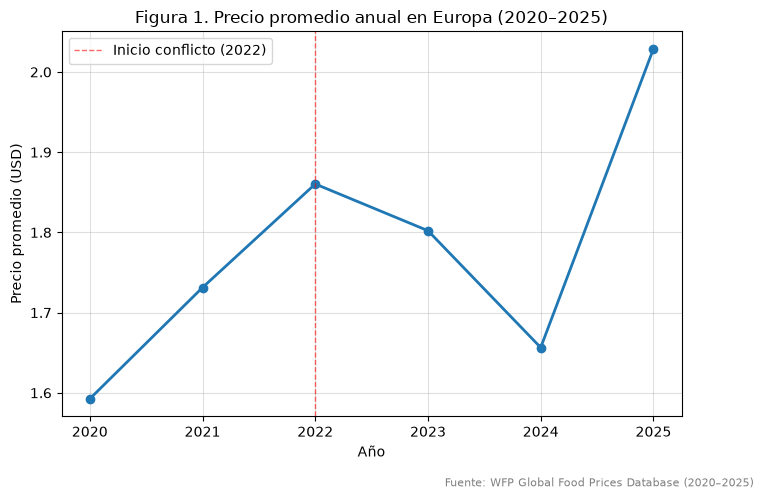

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    promedio_anual["year"],
    promedio_anual["usdprice"],
    marker="o",
    linewidth=2,
)

ax.axvline(2022, color="red", linestyle="--", linewidth=1, alpha=0.6,
           label="Inicio conflicto (2022)")

ax.set_title("Figura 1. Precio promedio anual en Europa (2020–2025)")
ax.set_xlabel("Año")
ax.set_ylabel("Precio promedio (USD)")
ax.legend()
ax.grid(True, alpha=0.4)

fig.text(0.99, -0.03, "Fuente: WFP Global Food Prices Database (2020–2025)",
          ha="right", fontsize=8, color="gray")

plt.savefig(
    "../results/grafico_precio_promedio.png",
    bbox_inches="tight",
    dpi=150,
)

plt.show()

## Interpretación

Durante el período 2020–2025 se observa una tendencia general al alza en el precio promedio de los alimentos registrados en el dataset europeo. Entre 2020 y 2022 el precio promedio aumentó desde aproximadamente 1,59 USD hasta 1,86 USD, lo que representa el mayor crecimiento sostenido del período analizado.

Posteriormente se observa una disminución moderada durante 2023 y 2024, seguida por un nuevo incremento significativo en 2025, alcanzando el valor promedio más alto de toda la serie (2,03 USD).

Si bien el aumento observado coincide temporalmente con el inicio del conflicto entre Rusia y Ucrania en 2022, los resultados deben interpretarse con cautela. Los precios de los alimentos están influenciados por múltiples factores económicos y geopolíticos, entre ellos las interrupciones en las cadenas de suministro, el aumento de los costos energéticos y de transporte, los procesos inflacionarios posteriores a la pandemia de COVID-19, las políticas monetarias adoptadas por distintos países y las variaciones en la oferta y demanda internacional de productos agrícolas.

Por lo tanto, los resultados sugieren una asociación temporal entre el período posterior a 2022 y el incremento de precios observado en el dataset, pero no permiten establecer una relación causal directa entre el conflicto y las variaciones registradas.

## 3. Visualización 2 — Top 10 productos con mayor variación porcentual

### Justificación analítica

Se reutiliza la clase `AnalizadorVariacionPrecios` implementada en Fase 3, aplicando el principio de no duplicar lógica ya validada (DRY). Este gráfico identifica los productos con mayor aumento porcentual acumulado, lo que permite enfocar el análisis en los casos más afectados dentro del dataset.

Se excluyen productos farmacéuticos (antibióticos, vasodilatadores) del ranking, ya que sus variaciones porcentuales responden a dinámicas de mercado ajenas al objetivo del proyecto — que se centra en alimentos — y podrían distorsionar la lectura del gráfico.

In [6]:
analizador = AnalizadorVariacionPrecios(df)

df_variaciones = (
    analizador
    .calcular_variaciones_anuales()
    .dropna()
)

excluir = [
    "Vasodilating agents (imported)",
    "Vasodilating agents (local)",
    "Antibiotics (local)",
    "Antibiotics (imported)",
]

top_aumentos = (
    df_variaciones
    .loc[~df_variaciones["commodity"].isin(excluir)]
    .sort_values("variacion_pct", ascending=False)
    .head(10)
)

top_aumentos

,commodity,year,precio_promedio,variacion_pct
112,Cabbage,2022,0.701232,156.548250
363,Onions,2022,0.704462,121.777545
118,Carrots,2022,0.701190,96.601930
164,Cucumbers,2022,1.240938,92.617385
29,Apples,2025,1.237320,83.387635
176,Eggplants,2022,1.275000,74.110953
443,Tomatoes,2022,1.151481,72.907480
387,Potatoes,2024,0.588198,72.871809
54,Beetroots,2022,0.635348,69.104027
53,Beetroots,2021,0.375714,61.145266


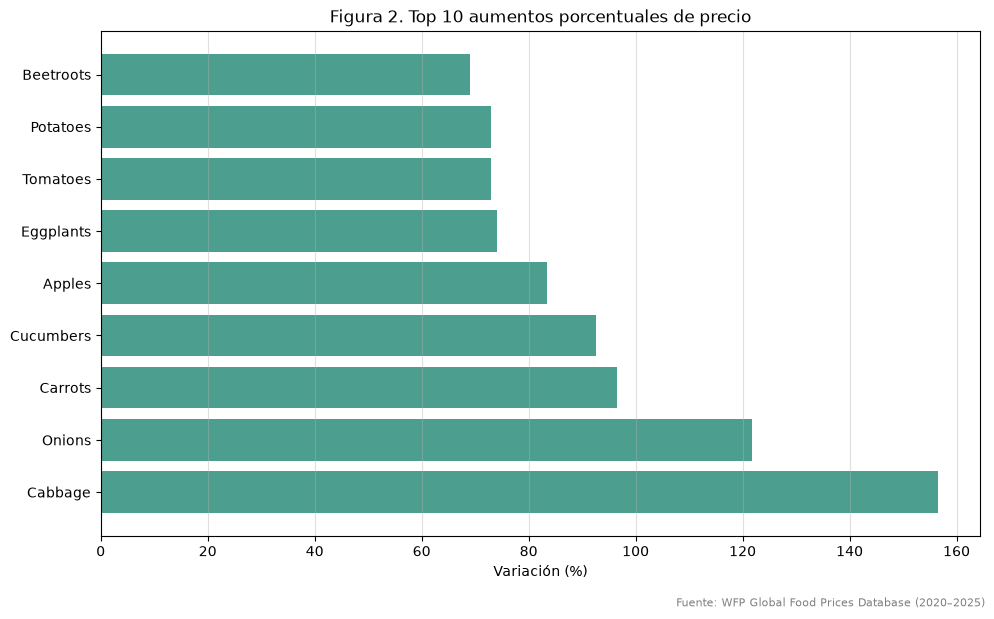

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_aumentos["commodity"],
    top_aumentos["variacion_pct"],
    color="#4C9F8E",
)

ax.set_title("Figura 2. Top 10 aumentos porcentuales de precio")
ax.set_xlabel("Variación (%)")
ax.grid(axis="x", alpha=0.4)

fig.text(0.99, -0.02, "Fuente: WFP Global Food Prices Database (2020–2025)",
          ha="right", fontsize=8, color="gray")

plt.tight_layout()

plt.savefig(
    "../results/grafico_top_aumentos.png",
    bbox_inches="tight",
    dpi=150,
)

plt.show()

### Interpretación

Los resultados muestran que los mayores incrementos porcentuales observados entre 2020 y 2025 se concentraron principalmente en productos agrícolas frescos y de consumo habitual. Entre ellos destacan el repollo (Cabbage), con un aumento cercano al 156%, y la cebolla (Onions), con una variación superior al 120%.

También se registraron incrementos importantes en zanahorias, pepinos, manzanas, berenjenas, tomates y papas. En conjunto, estos resultados sugieren que los productos hortofrutícolas experimentaron una presión de precios superior al promedio general observado durante el período analizado.

El gráfico evidencia los diez productos con mayor variación porcentual acumulada dentro del período analizado, una vez excluidos los productos farmacéuticos. Se espera que los mayores incrementos se concentren en productos agrícolas frescos, cuya cadena de producción y distribución es más sensible a disrupciones logísticas, climáticas y de costos energéticos.

Aunque el conflicto entre Rusia y Ucrania constituye un elemento contextual relevante debido a la participación de ambos países en los mercados agrícolas internacionales, los resultados obtenidos no permiten establecer una relación causal directa. Más bien, evidencian que determinados productos agrícolas experimentaron incrementos de precio considerablemente superiores al promedio general registrado entre 2020 y 2025.

Esta visualización complementa a la Figura 1: mientras el precio promedio agregado entrega una visión general, el ranking de variaciones por producto permite identificar qué alimentos específicos explican en mayor medida los cambios observados a nivel agregado.

## 4. Visualización 3 — Evolución temporal de productos seleccionados

### Justificación analítica

Se seleccionan tres productos representativos de distintas categorías alimentarias —pan (cereal procesado), leche (lácteo) y cebolla (vegetal fresco)— para comparar su comportamiento individual a lo largo del tiempo. Esta selección permite observar si la evolución de precios fue homogénea entre categorías o si existieron comportamientos diferenciados, complementando la mirada agregada de la Figura 1 y el ranking de la Figura 2.

In [8]:
productos = [
    "Bread (high grade flour)",
    "Milk",
    "Onions",
]

df_productos = df[df["commodity"].isin(productos)]

evolucion = (
    df_productos
    .groupby(["year", "commodity"])["usdprice"]
    .mean()
    .reset_index()
)

evolucion

,year,commodity,usdprice
0,2020,Bread (high grade flour),0.919805
1,2020,Milk,0.922695
2,2020,Onions,0.351222
3,2021,Bread (high grade flour),1.063344
4,2021,Milk,0.974800
5,2021,Onions,0.317643
6,2022,Bread (high grade flour),1.138556
7,2022,Milk,0.994980
8,2022,Onions,0.704462
9,2023,Bread (high grade flour),1.100530


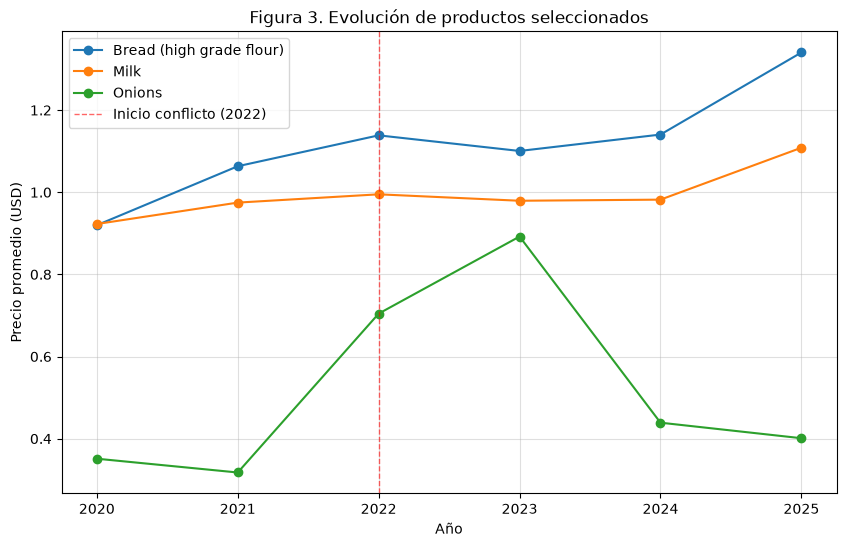

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

for producto in productos:
    datos = evolucion[evolucion["commodity"] == producto]
    ax.plot(datos["year"], datos["usdprice"], marker="o", label=producto)
    
ax.axvline(2022, color="red", linestyle="--", linewidth=1, alpha=0.6,
           label="Inicio conflicto (2022)")
ax.set_title("Figura 3. Evolución de productos seleccionados")
ax.set_xlabel("Año")
ax.set_ylabel("Precio promedio (USD)")
ax.legend()
ax.grid(True, alpha=0.4)




plt.savefig(
    "../results/grafico_productos_seleccionados.png",
    bbox_inches="tight",
    dpi=150,
)

plt.show()

## Interpretación

Los resultados muestran comportamientos distintos entre los productos seleccionados durante el período 2020–2025. El pan (Bread - high grade flour) presenta una tendencia general de crecimiento, pasando de aproximadamente 0,92 USD en 2020 a 1,34 USD en 2025. Aunque se observa una leve disminución en 2023, la tendencia global es claramente ascendente.

La leche (Milk) exhibe un comportamiento más estable, con incrementos moderados a lo largo del período. Su precio promedio aumenta desde aproximadamente 0,92 USD en 2020 hasta 1,11 USD en 2025, mostrando una menor volatilidad en comparación con los otros productos analizados.

Por su parte, la cebolla (Onions) presenta el comportamiento más variable. Entre 2021 y 2023 registra un aumento considerable, alcanzando un máximo cercano a 0,89 USD, pero posteriormente experimenta una disminución importante durante 2024 y 2025. Este patrón sugiere una mayor sensibilidad a cambios en las condiciones de oferta y demanda, así como a factores externos que afectan la producción agrícola.

En conjunto, los resultados evidencian que la evolución de los precios no fue homogénea entre todos los alimentos. Mientras algunos productos muestran incrementos sostenidos durante todo el período, otros presentan fluctuaciones significativas, lo que refuerza la idea de que múltiples factores económicos, logísticos y productivos influyen en la formación de precios dentro de los mercados alimentarios europeos.

## 5. Validación y reflexión técnica

### Validaciones aplicadas en esta fase

Las validaciones formales del dataset (duplicados, nulos, rango de años) ya fueron ejecutadas dentro del método `validar()` de `Preprocesador` al momento de construir `df`. Adicionalmente, se verifica aquí que el dataset contenga la información mínima necesaria para las visualizaciones de esta fase.

In [10]:
assert not promedio_anual.empty, "No hay datos de precio promedio anual."
assert len(top_aumentos) == 10, "El ranking de variaciones no tiene 10 productos."
assert set(productos).issubset(df["commodity"].unique()), \
    "Alguno de los productos seleccionados no está presente en el dataset."

print("Validaciones superadas correctamente.")

Validaciones superadas correctamente.


## 6. Discusión

### Contraste con la hipótesis inicial

La hipótesis inicial del proyecto planteaba que el conflicto Rusia-Ucrania, iniciado en febrero de 2022, podría asociarse con un incremento en los precios de alimentos en los países europeos disponibles en la base WFP. Las tres visualizaciones desarrolladas son consistentes con esa hipótesis en términos de asociación temporal, aunque no permiten establecer causalidad.

### Limitaciones

- El dataset no contiene información para la totalidad de los países europeos, sino solo aquellos disponibles en la cobertura del WFP.
- La comparación antes/después del conflicto es de carácter exploratorio y descriptivo, no causal.
- El uso de precios promedio puede ocultar diferencias relevantes entre mercados, regiones o unidades de medida específicas.
- Factores externos no modelados explícitamente (inflación global, costos energéticos, políticas económicas, estacionalidad) pueden influir en los resultados observados.

### Riesgos de interpretación

Atribuir el incremento de precios exclusivamente al conflicto sería una sobre-simplificación. El análisis presentado debe leerse como evidencia de asociación temporal, no como prueba de un mecanismo causal único.

## 7. Conclusiones

Las visualizaciones desarrolladas permitieron identificar tendencias relevantes en la evolución de los precios de los alimentos en Europa durante el período 2020–2025. En términos generales, se observa una tendencia al alza en el precio promedio de los productos analizados, aunque con variaciones importantes entre distintas categorías alimentarias.

El análisis mostró que ciertos productos agrícolas frescos registraron incrementos porcentuales considerablemente superiores al promedio general. Asimismo, la evolución temporal de productos específicos evidenció comportamientos diferenciados, con algunos alimentos presentando aumentos sostenidos y otros mostrando fluctuaciones significativas entre años.

Los resultados sugieren que la evolución de los precios responde a una combinación de factores económicos, logísticos y productivos. Entre ellos pueden mencionarse las variaciones en los costos de energía, transporte y fertilizantes, las alteraciones en las cadenas de suministro internacionales, los efectos posteriores a la pandemia y el contexto geopolítico asociado al conflicto entre Rusia y Ucrania.

No obstante, el análisis realizado tiene un carácter exploratorio y descriptivo. Si bien se identifican asociaciones temporales entre determinados eventos y la evolución de los precios, los resultados no permiten establecer relaciones causales directas. En consecuencia, las visualizaciones constituyen una herramienta para comprender tendencias y patrones observados en los datos, proporcionando una base sólida para futuros análisis más específicos.

Finalmente, la integración de las fases del proyecto permitió construir un flujo reproducible que abarca la definición del problema, el preprocesamiento desde archivos raw, el análisis algorítmico orientado a objetos y la comunicación visual de resultados, cumpliendo los objetivos planteados para el desarrollo del proyecto.